In [1]:
import json
import os

import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE

import dnnlib
from training.testers import EGCTester, WRNTester

/home/lorenzo/miniconda3/envs/edm/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model_type = "egc"
dataset = "bloodmnist_256"
dataset_dir=f"./data/{dataset}"
strategy="lc"
seed = 0
kwargs = {
    "model_type": model_type,
    "outdir": f"./{model_type}-runs/{dataset}/{strategy}/0000{seed}-run",
    "test_dir": f"{dataset_dir}/test",
    "ckpt_type": "best",
    "train_on_latents": True,
}
opts = dnnlib.EasyDict(kwargs)
tester_kwargs = dnnlib.EasyDict()

tester_kwargs.test_dataset_kwargs = dnnlib.EasyDict(
    class_name="training.dataset.ImageFolderDataset",
    use_labels=True,
    path=opts.test_dir,
)

with open(os.path.join(opts.outdir, "network_kwargs.json"), "r") as f:
    network_kwargs = json.load(f)

tester_kwargs.network_kwargs = network_kwargs
tester_kwargs.outdir = opts.outdir
tester_kwargs.ckpt_type = opts.ckpt_type
tester_kwargs.train_on_latents = opts.train_on_latents

ckpt_list = [os.path.join(root, file) for root, _, files in os.walk(tester_kwargs.outdir) for file in files if file.endswith(".pt")]
ckpt_list = [ckpt for ckpt in ckpt_list if opts.ckpt_type in ckpt]

match opts.model_type:
    case "wrn":
        tester = WRNTester(**tester_kwargs)
    case "egc":
        tester = EGCTester(**tester_kwargs)
    case _:
        raise ValueError(f"Unknown model type: {opts.model_type}")

Loading test dataset...
Constructing network...


In [3]:
features, labels, images_list, indices_list = tester.get_features_and_labels(tester.ema.ema_model, ckpt_list[-1])

Testing: 100%|██████████| 27/27 [01:05<00:00,  2.44s/it]


In [4]:
tsne = TSNE(n_components=2, random_state=42)
features_2d = tsne.fit_transform(features)

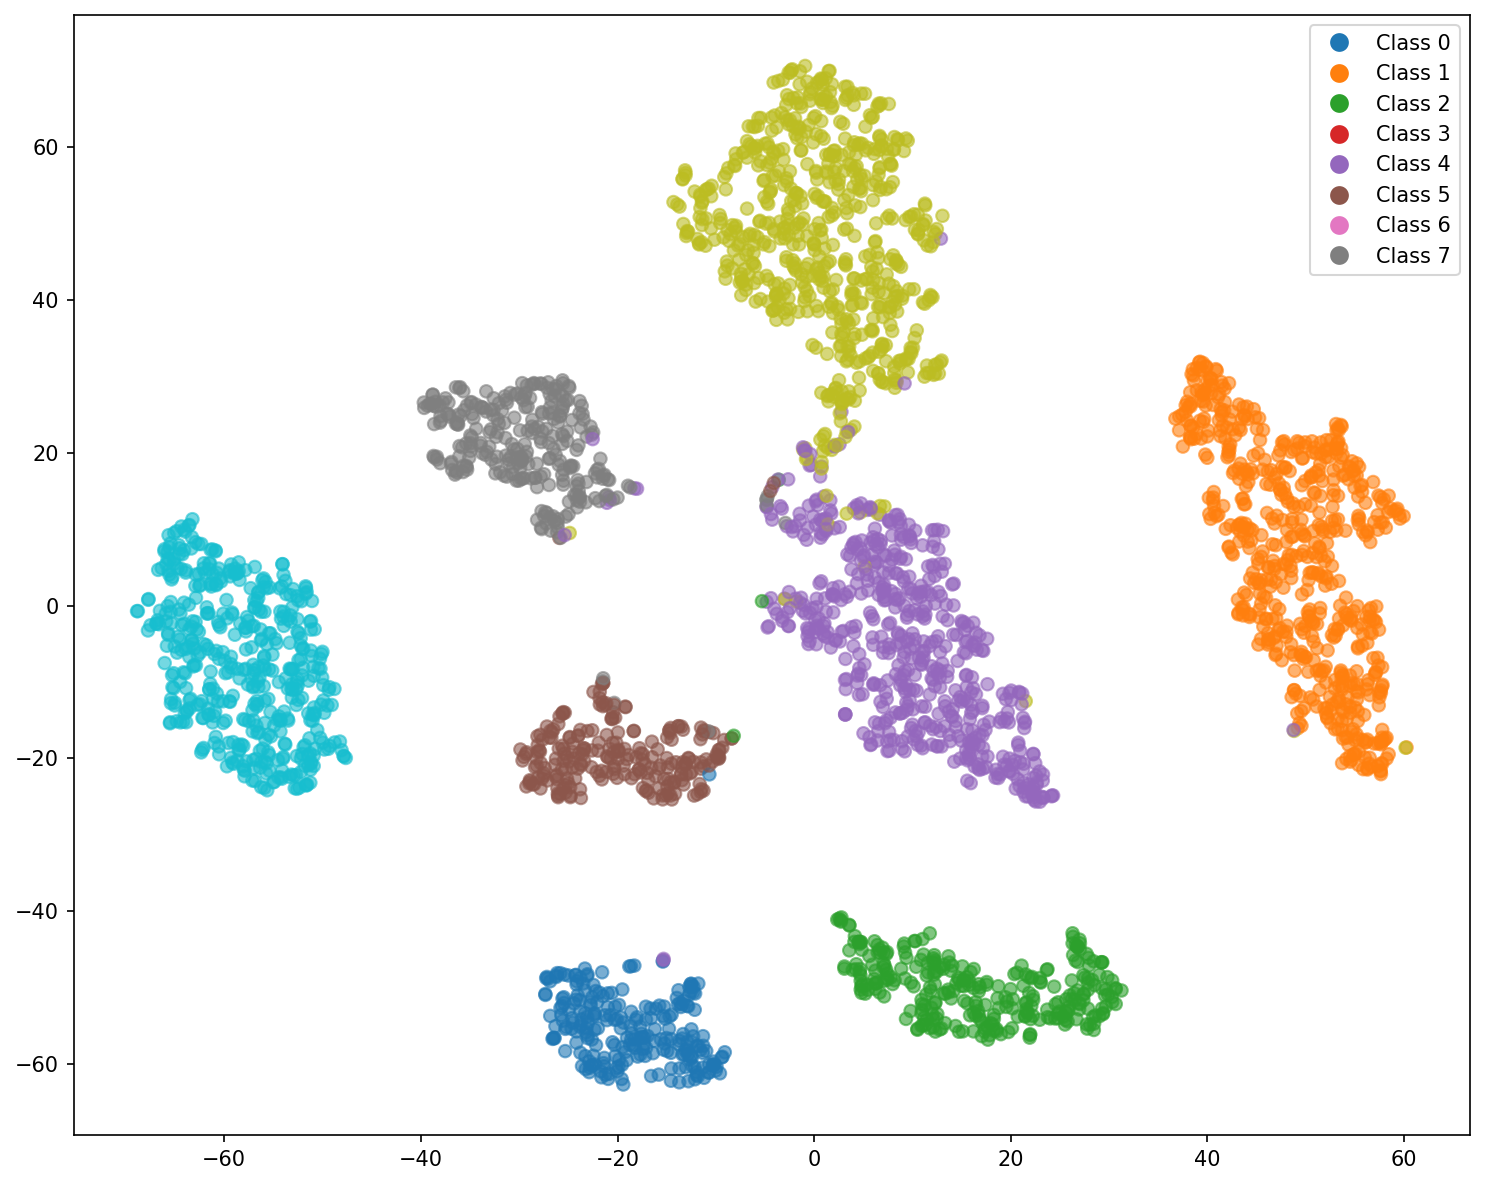

In [ ]:
# Plot
plt.figure(figsize=(10, 8), dpi=150)
scatter = plt.scatter(features_2d[:, 0], features_2d[:, 1], c=labels, cmap='tab10', alpha=0.6)

unique_labels = np.unique(labels)
legend_elements = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=plt.cm.tab10(i/10), label=f'Class {c}', markersize=10) for i, c in enumerate(unique_labels)]
plt.legend(handles=legend_elements)
plt.tight_layout()
plt.show()

Most confused class pairs: [(np.int64(3), np.int64(6)), (np.int64(3), np.int64(5)), (np.int64(4), np.int64(5))]


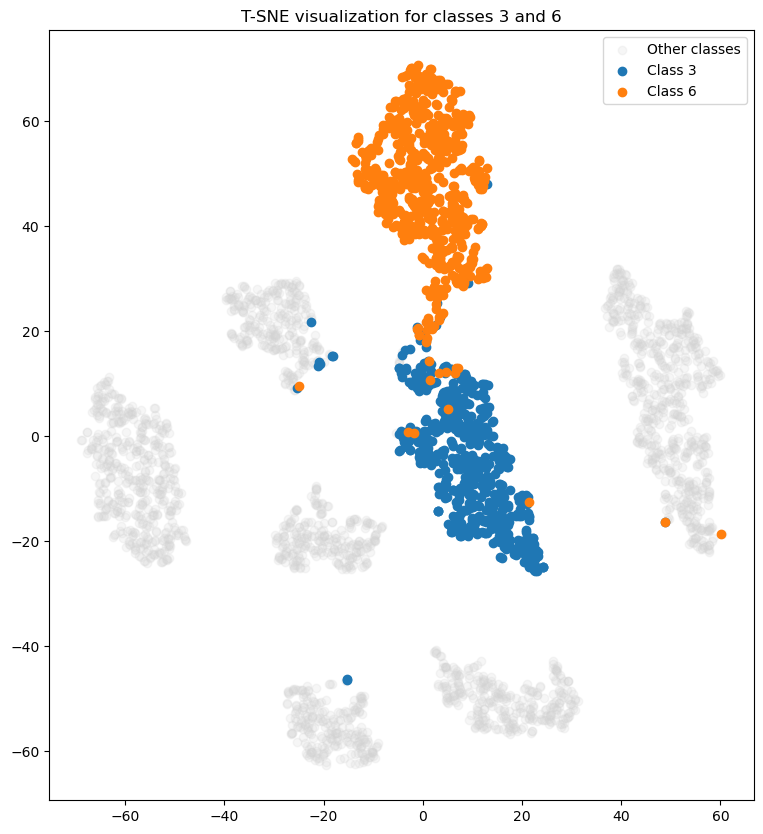

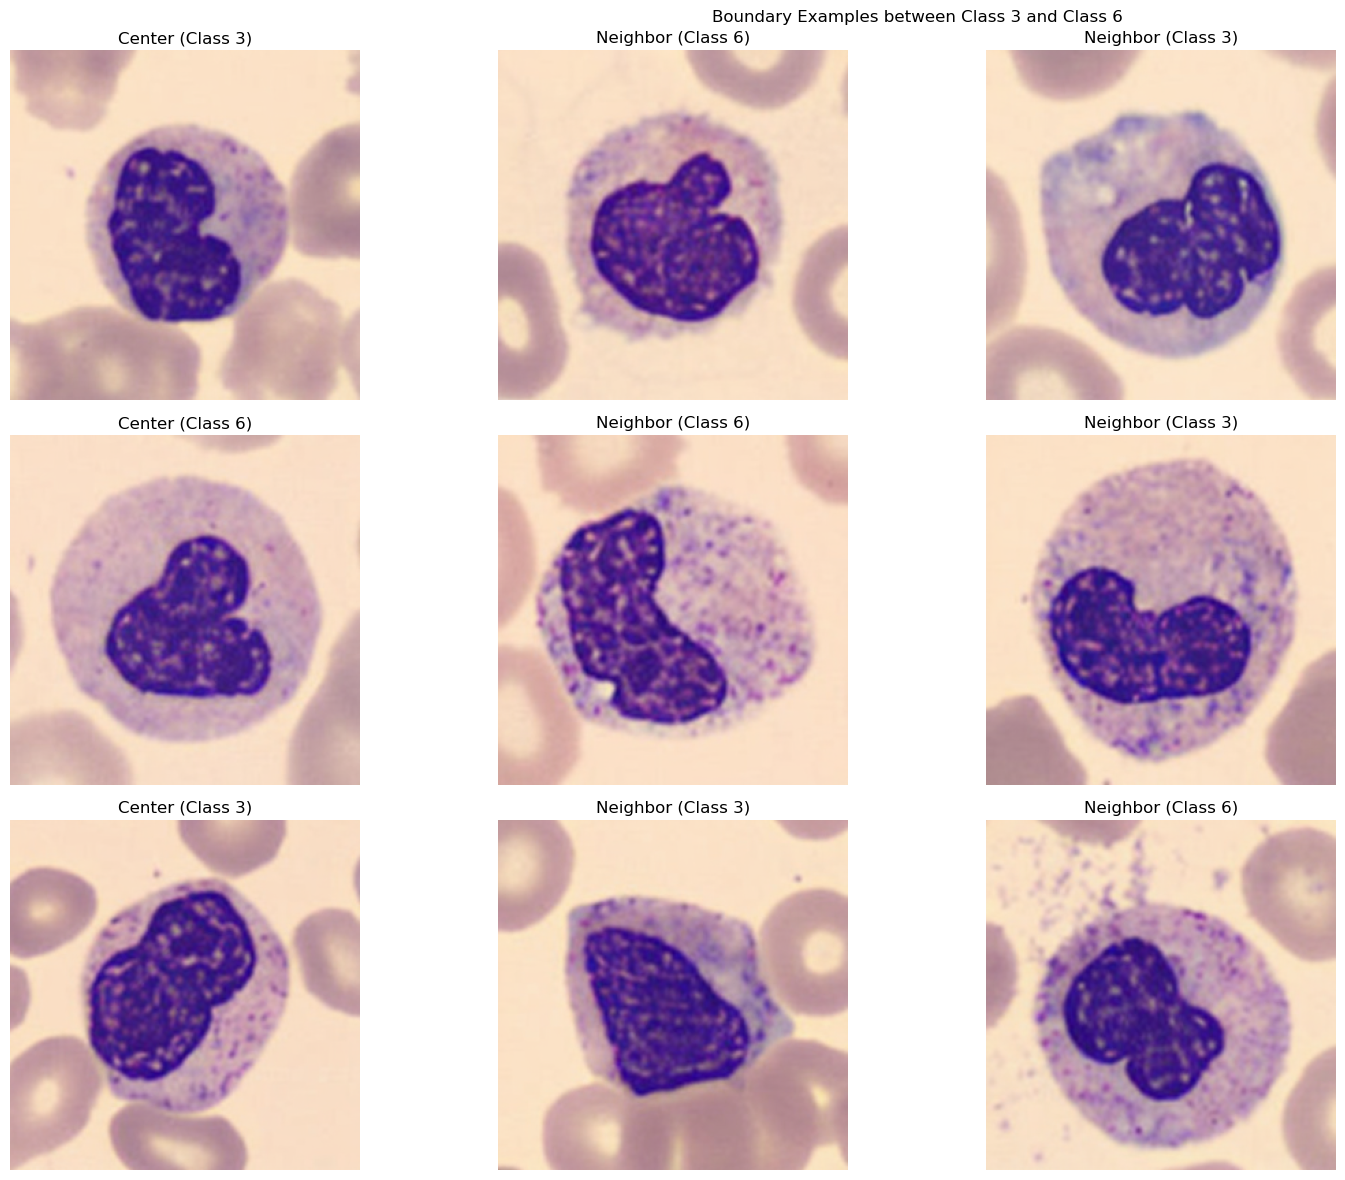

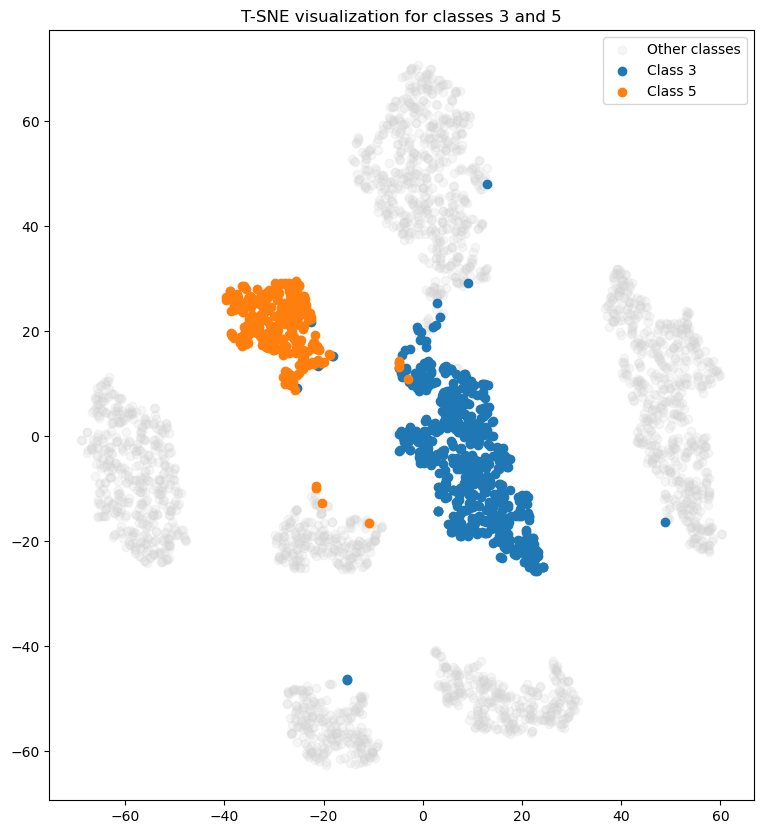

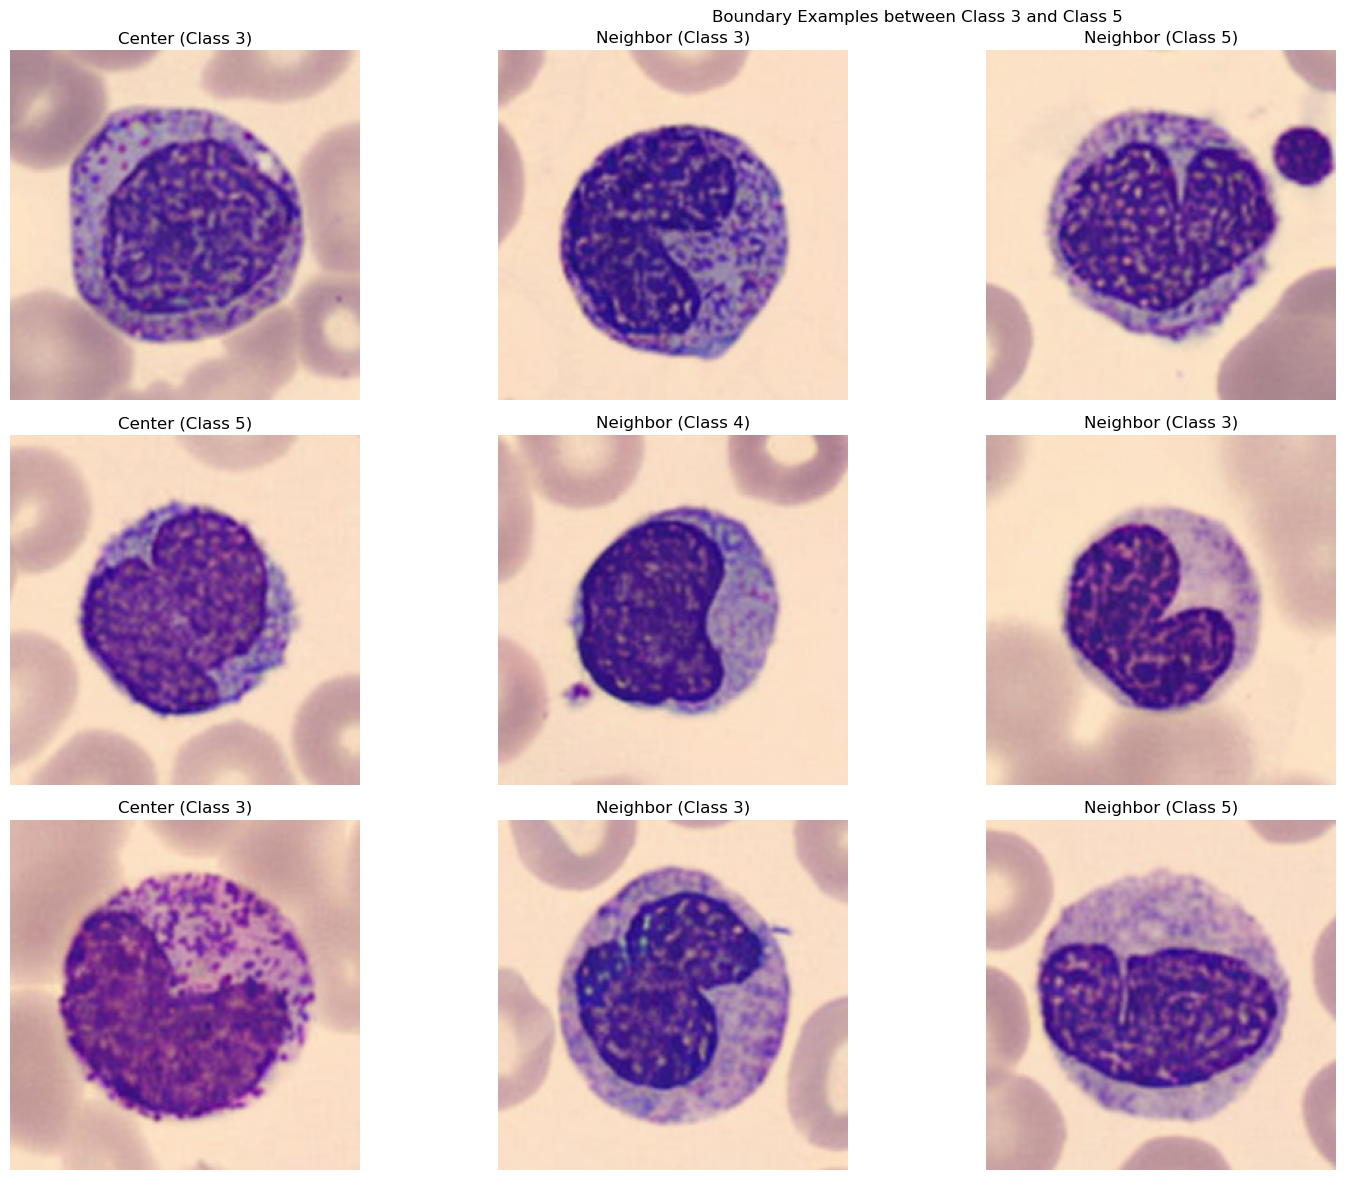

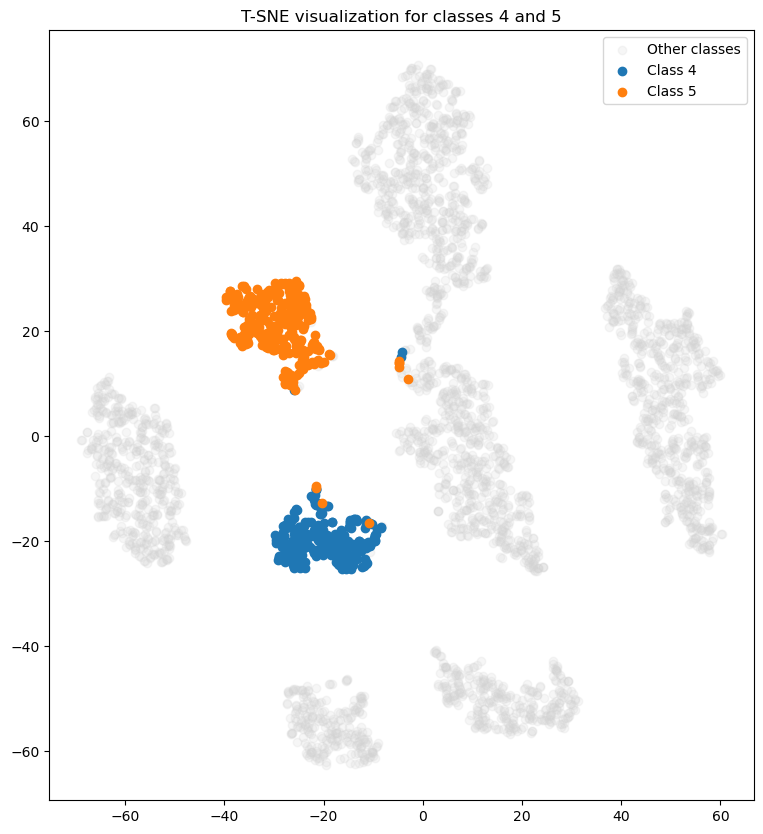

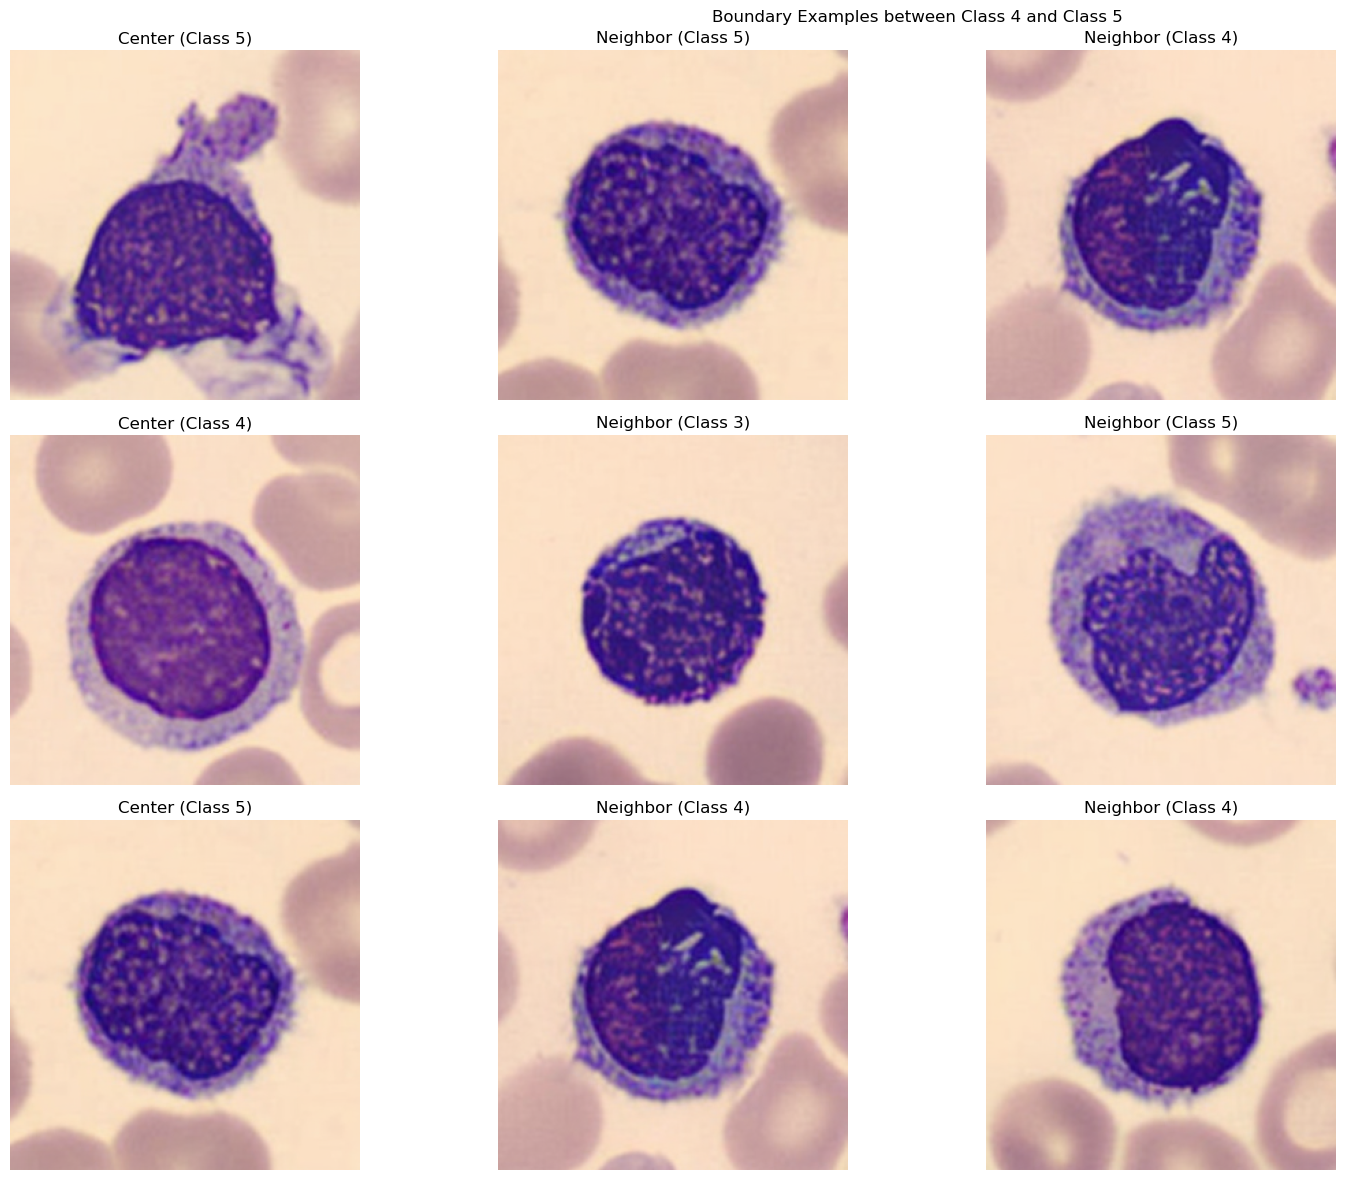

In [ ]:
import torch
from sklearn.neighbors import NearestNeighbors
            
nbrs = NearestNeighbors(n_neighbors=10).fit(features_2d)
distances, indices = nbrs.kneighbors(features_2d)

confusion_count = {}
for i in range(len(labels)):
    neighbor_labels = labels[indices[i]]
    for label in np.unique(neighbor_labels):
        if label != labels[i]:
            pair = tuple(sorted([labels[i], label]))
            confusion_count[pair] = confusion_count.get(pair, 0) + 1

# Get top confused pairs
class_pairs = sorted(confusion_count.items(), key=lambda x: x[1], reverse=True)[:3]
class_pairs = [pair[0] for pair in class_pairs]
print("Most confused class pairs:", class_pairs)

n_neighbors = 3
n_samples = 3
# Create visualization for each class pair
for class1, class2 in class_pairs:
    plt.figure(figsize=(20, 10))
    
    # Plot t-SNE with highlighted classes
    plt.subplot(1, 2, 1)
    mask = np.isin(labels, [class1, class2])
    plt.scatter(features_2d[~mask, 0], features_2d[~mask, 1], c='lightgray', alpha=0.2, label='Other classes')
    plt.scatter(features_2d[labels == class1, 0], features_2d[labels == class1, 1], label=f'Class {class1}')
    plt.scatter(features_2d[labels == class2, 0], features_2d[labels == class2, 1], label=f'Class {class2}')
    plt.title(f'T-SNE visualization for classes {class1} and {class2}')
    plt.legend()

    # Find boundary points between these classes
    class1_points = features_2d[labels == class1]
    class2_points = features_2d[labels == class2]
    
    # Find points from class1 that have neighbors from class2 and vice versa
    nbrs = NearestNeighbors(n_neighbors=n_neighbors).fit(features_2d)
    boundary_points = []
    
    for idx in np.where(labels == class1)[0]:
        distances, neighbor_indices = nbrs.kneighbors(features_2d[idx:idx+1])
        if any(labels[neighbor_indices[0]] == class2):
            boundary_points.append((idx, neighbor_indices[0]))
            
    for idx in np.where(labels == class2)[0]:
        distances, neighbor_indices = nbrs.kneighbors(features_2d[idx:idx+1])
        if any(labels[neighbor_indices[0]] == class1):
            boundary_points.append((idx, neighbor_indices[0]))

    # Sample boundary points
    if len(boundary_points) > n_samples:
        selected_points = np.random.choice(len(boundary_points), n_samples, replace=False)
        boundary_points = [boundary_points[i] for i in selected_points]

    # Visualize boundary examples
    fig = plt.figure(figsize=(20, 4 * len(boundary_points)))
    for i, (center_idx, neighbor_indices) in enumerate(boundary_points):
        # Plot center image and its neighbors
        plt.subplot(len(boundary_points), n_neighbors + 1, i * (n_neighbors + 1) + 1)
        center_img = images_list[indices_list[center_idx]]
        if isinstance(center_img, torch.Tensor):
            center_img = center_img.permute(1, 2, 0).numpy()
        plt.imshow(center_img)
        plt.title(f'Center (Class {labels[center_idx]})')
        plt.axis('off')
        
        # Plot nearest neighbors
        for j, idx in enumerate(neighbor_indices[1:n_neighbors]):  # Skip first as it's the point itself
            plt.subplot(len(boundary_points), n_neighbors + 1, i * (n_neighbors + 1) + j + 2)
            neighbor_img = images_list[indices_list[idx]]
            if isinstance(neighbor_img, torch.Tensor):
                neighbor_img = neighbor_img.permute(1, 2, 0).numpy()
            plt.imshow(neighbor_img)
            plt.title(f'Neighbor (Class {labels[idx]})')
            plt.axis('off')

    plt.suptitle(f'Boundary Examples between Class {class1} and Class {class2}')
    plt.tight_layout()
    plt.show()